# Koalas_Dask - Large Dataset

**Summary of this Notebook:**

This notebook presents a comprehensive performance benchmarking study comparing Koalas (based on PySpark) and Dask, two popular distributed data processing frameworks in Python. The evaluation was conducted using a large dataset, allowing a controlled and focused analysis of execution behavior without the overhead of large-scale data.

The benchmarking includes a diverse set of operations to understand how each framework performs under different scenarios:

Standard Operations: A baseline comparison covering typical data processing tasks such as arithmetic operations, joins, groupby statistics, and file reading.

Filtering: Operations were executed on filtered datasets to reflect real-world usage where data is often subsetted based on specific conditions.

Filtering with Caching: To assess the impact of in-memory optimizations, we repeated the filtered operations with caching enabled.

Each test measured execution time across both frameworks, and results were compared using both absolute timings and relative performance ratios. The goal is to identify strengths and weaknesses in each framework’s execution model and provide guidance on their suitability for different data processing tasks.

In [1]:
import pandas as pd

In [2]:
df = pd.read_parquet("Samples/balanced_large.parquet")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650008 entries, 0 to 3650007
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   vendor_name            object        
 1   Trip_Pickup_DateTime   datetime64[ns]
 2   Trip_Dropoff_DateTime  object        
 3   Passenger_Count        int64         
 4   Trip_Distance          float64       
 5   Start_Lon              float64       
 6   Start_Lat              float64       
 7   End_Lon                float64       
 8   End_Lat                float64       
 9   Payment_Type           object        
 10  Fare_Amt               float64       
 11  surcharge              float64       
 12  Tip_Amt                float64       
 13  Tolls_Amt              float64       
 14  Total_Amt              float64       
 15  year                   int64         
 16  month                  int64         
 17  day                    int64         
 18  hour                  

**Load and Clean Dataset**

The dataset is first loaded using Pandas and its index is reset to avoid hidden columns.
Then, a cleaned version is saved as a new .parquet file to ensure consistency before benchmarking.

In [ ]:
# Step 1: Load with Pandas and reset index
df = pd.read_parquet("Samples/balanced_large.parquet")
df = df.reset_index()  # Ensures no hidden index column remains

# Step 2: Save a clean version
df.to_parquet("Samples/sample_2009_2010_large_clean.parquet", index=False)

# Benchmark 

**Prepare Koalas Environment with PySpark Compatibility**

To ensure compatibility between workers and driver, both are explicitly set to use the same Python version (3.7).
The JAVA_HOME path is also defined to properly run Spark-based operations in the environment.

**Set-up**

In [ ]:
# ENSURE THAT WORKERS AND DRIVER RUN THE SAME PYTHON VERSION

import os
import sys

# Set both to the same Python version
os.environ["PYSPARK_PYTHON"] = "/opt/conda/envs/cdle/bin/python3.7"
os.environ["PYSPARK_DRIVER_PYTHON"] = "/opt/conda/envs/cdle/bin/python3.7"
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"

print(sys.executable)
print(sys.version)


# Suppress warnings for cleaner output
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

/opt/conda/envs/cdle/bin/python
3.7.12 | packaged by conda-forge | (default, Oct 26 2021, 06:08:21) 
[GCC 9.4.0]


**Initialize Spark Session and Configure Runtime**

A Spark session is initialized with specific Python executables to match PySpark requirements.
Additionally, the Databricks I/O cache is disabled to measure raw execution times without caching effects.

In [ ]:
from pyspark.sql import SparkSession

# Initialize Spark session with defined Python executables
spark = SparkSession.builder \
    .appName("project") \
    .config("spark.pyspark.python", "/usr/bin/python3.7") \
    .config("spark.pyspark.driver.python", "/usr/bin/python3.7") \
    .getOrCreate()

# Set log level to ERROR to hide warnings
spark.sparkContext.setLogLevel("ERROR")

# Disable caching to benchmark raw performance
spark.conf.set("spark.databricks.io.cache.enabled", "false")
print("spark.databricks.io.cache.enabled is %s" % spark.conf.get("spark.databricks.io.cache.enabled"))

spark.databricks.io.cache.enabled is false


In [8]:
print(spark.sparkContext.getConf().get("spark.pyspark.python"))
print(spark.sparkContext.getConf().get("spark.pyspark.driver.python"))

/usr/bin/python3.7
/usr/bin/python3.7


**Import Required Libraries and Verify Environment Versions**

All necessary libraries—pandas, numpy, koalas, dask, pyarrow, pyspark—are imported.
Library versions are printed to ensure consistency and reproducibility across benchmarks.

FutureWarnings are suppressed to keep the output clean and focused during benchmarking.
This avoids noise in logs, especially when using evolving libraries like Koalas and Dask.

In [ ]:
# Import all required libraries and check versions
import pandas as pd
import numpy as np
import pyspark
import pyarrow
import databricks.koalas as ks
import dask.dataframe as dd
from dask.distributed import Client, LocalCluster
 
print('pandas version: %s' % pd.__version__)
print('numpy version: %s' % np.__version__)
print('koalas version: %s' % ks.__version__)
print("pyspark version:", pyspark.__version__)
print("pyarrow version:", pyarrow.__version__)

import dask
print('dask version: %s' % dask.__version__)
 
import time

pandas version: 1.1.5
numpy version: 1.19.5
koalas version: 1.7.0
pyspark version: 3.4.4
pyarrow version: 1.0.1
dask version: 2022.02.0


**Benchmark**

Benchmarking was performed on each operation using the custom benchmark function.
This function recorded the execution time of each task on the Koalas DataFrame and stored the results for later analysis. It enabled a systematic comparison of operation durations across different processing scenarios.

In [10]:
def benchmark(f, df, benchmarks, name, **kwargs):
    """Benchmark the given function against the given DataFrame.
    
    Parameters
    ----------
    f: function to benchmark
    df: data frame
    benchmarks: container for benchmark results
    name: task name
    
    Returns
    -------
    Duration (in seconds) of the given operation
    """
    start_time = time.time()
    ret = f(df, **kwargs)
    benchmarks['duration'].append(time.time() - start_time)
    benchmarks['task'].append(name)
    print(f"{name} took: {benchmarks['duration'][-1]} seconds")
    return benchmarks['duration'][-1]
 
def get_results(benchmarks):
    """Return a pandas DataFrame containing benchmark results."""
    return pd.DataFrame.from_dict(benchmarks)

# Dataset Information
#### Regular Dataset

The clean Parquet dataset was loaded using Koalas.

Three separate benchmark containers were initialized (koalas_benchmarks, koalas_benchmarks_filtered, and koalas_benchmarks_cache) to store execution times for the full, filtered, and cached scenarios respectively.

In [ ]:
# Load cleaned dataset with Koalas
koalas_data = ks.read_parquet("Samples/sample_2009_2010_large_clean.parquet")

# Initialize benchmark containers for each scenario
koalas_benchmarks = {
    'duration': [],  # in seconds
    'task': [],
}

koalas_benchmarks_filtered = {
    'duration': [],  # in seconds
    'task': [],
}

koalas_benchmarks_cache = {
    'duration': [],  # in seconds
    'task': [],
}

In [12]:
koalas_data.info()

<class 'databricks.koalas.frame.DataFrame'>
Int64Index: 3650008 entries, 0 to 3650007
Data columns (total 20 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   index                  3650008 non-null  int64         
 1   vendor_name            3650008 non-null  object        
 2   Trip_Pickup_DateTime   3650008 non-null  datetime64[ns]
 3   Trip_Dropoff_DateTime  3650008 non-null  object        
 4   Passenger_Count        3650008 non-null  int64         
 5   Trip_Distance          3650008 non-null  float64       
 6   Start_Lon              3650008 non-null  float64       
 7   Start_Lat              3650008 non-null  float64       
 8   End_Lon                3650008 non-null  float64       
 9   End_Lat                3650008 non-null  float64       
 10  Payment_Type           3650008 non-null  object        
 11  Fare_Amt               3650008 non-null  float64       
 12  surcharge             

In [ ]:
# Display the first 10 rows of the loaded Koalas DataFrame
koalas_data.head(10)

,index,vendor_name,Trip_Pickup_DateTime,Trip_Dropoff_DateTime,Passenger_Count,Trip_Distance,Start_Lon,Start_Lat,End_Lon,End_Lat,Payment_Type,Fare_Amt,surcharge,Tip_Amt,Tolls_Amt,Total_Amt,year,month,day,hour
0,0,CMT,2009-01-01 00:45:16,2009-01-01 01:01:48,1,4.8,-73.955986,40.776054,-73.978488,40.728903,Cash,15.0,0.0,0.00,0.0,15.00,2009,1,1,0
1,1,CMT,2009-01-01 00:30:50,2009-01-01 00:34:37,1,0.4,-73.993314,40.744723,-73.985561,40.741991,Cash,4.6,0.0,0.00,0.0,4.60,2009,1,1,0
2,2,CMT,2009-01-01 00:39:49,2009-01-01 00:47:58,1,1.9,-73.969583,40.769001,-73.975622,40.787921,Cash,7.8,0.0,0.00,0.0,7.80,2009,1,1,0
3,3,CMT,2009-01-01 00:47:32,2009-01-01 00:56:22,1,1.6,-73.950814,40.779275,-73.965337,40.759277,Cash,7.8,0.0,0.00,0.0,7.80,2009,1,1,0
4,4,CMT,2009-01-01 00:26:15,2009-01-01 00:26:38,1,0.1,-73.926332,40.808143,-73.928372,40.808988,Cash,3.0,0.0,0.00,0.0,3.00,2009,1,1,0
5,5,CMT,2009-01-01 00:38:29,2009-01-01 00:59:03,3,7.8,-74.003245,40.733577,-73.963703,40.810218,Credit,21.0,0.0,5.25,0.0,26.25,2009,1,1,0
6,6,CMT,2009-01-01 00:41:06,2009-01-01 00:50:13,2,1.0,-73.990086,40.740832,-73.980446,40.746520,Cash,7.0,0.0,0.00,0.0,7.00,2009,1,1,0
7,7,DDS,2009-01-01 00:11:46,2009-01-01 00:25:06,2,1.6,-73.994876,40.755437,-73.983055,40.739024,CREDIT,8.1,0.5,2.00,0.0,10.60,2009,1,1,0
8,8,CMT,2009-01-01 00:36:12,2009-01-01 01:10:28,2,5.6,-73.953678,40.784593,-73.983188,40.729943,Cash,21.4,0.0,0.00,0.0,21.40,2009,1,1,0
9,9,CMT,2009-01-01 00:02:14,2009-01-01 00:09:26,1,1.5,-74.001634,40.730793,-73.991639,40.748866,Cash,6.6,0.0,0.00,0.0,6.60,2009,1,1,0


#### Standart Operations

A set of data processing functions was defined for benchmarking purposes.
These functions cover common operations such as aggregations, arithmetic computations, statistical summaries, groupby operations, and joins, enabling performance evaluation across a variety of tasks.


In [ ]:
# Define a set of utility functions to perform various data operations for benchmarking

def read_file_parquet(df=None):
    return ks.read_parquet("Samples/sample_2009_2010_large_clean.parquet")

def count(df=None):
    return len(df)
 
def count_index_length(df=None):
    return len(df.index)
 
def mean(df):
    return df.Fare_Amt.mean()
 
def standard_deviation(df):
    return df.Fare_Amt.std()
 
def mean_of_sum(df):
    return (df.Fare_Amt + df.Tip_Amt).mean()
 
def sum_columns(df):
    x = df.Fare_Amt + df.Tip_Amt
    x.to_pandas()
    return x
 
def mean_of_product(df):
    return (df.Fare_Amt * df.Tip_Amt).mean()
 
def product_columns(df):
    x = df.Fare_Amt * df.Tip_Amt
    x.to_pandas()
    return x
 
def value_counts(df):
    val_counts = df.Fare_Amt.value_counts()
    val_counts.to_pandas()
    return val_counts
  
def complicated_arithmetic_operation(df):
    theta_1 = df.Start_Lon
    phi_1 = df.Start_Lat
    theta_2 = df.End_Lon
    phi_2 = df.End_Lat
    temp = (np.sin((theta_2 - theta_1) / 2 * np.pi / 180) ** 2
           + np.cos(theta_1 * np.pi / 180) * np.cos(theta_2 * np.pi / 180) * np.sin((phi_2 - phi_1) / 2 * np.pi / 180) ** 2)
    ret = np.multiply(np.arctan2(np.sqrt(temp), np.sqrt(1-temp)),2)
    ret.to_pandas()
    return ret
  
def mean_of_complicated_arithmetic_operation(df):
    theta_1 = df.Start_Lon
    phi_1 = df.Start_Lat
    theta_2 = df.End_Lon
    phi_2 = df.End_Lat
    temp = (np.sin((theta_2 - theta_1) / 2 * np.pi / 180) ** 2
           + np.cos(theta_1 * np.pi / 180) * np.cos(theta_2 * np.pi / 180) * np.sin((phi_2 - phi_1) / 2 * np.pi / 180) ** 2)
    ret = np.multiply(np.arctan2(np.sqrt(temp), np.sqrt(1-temp)),2) 
    return ret.mean()
  
def groupby_statistics(df):
    gb = df.groupby(by='Passenger_Count').agg(
      {
        'Fare_Amt': ['mean', 'std'], 
        'Tip_Amt': ['mean', 'std']
      }
    )
    gb.to_pandas()
    return gb
  
# Create helper dataframe for joining
other = ks.DataFrame(groupby_statistics(koalas_data).to_pandas())
other.columns = pd.Index([e[0]+'_' + e[1] for e in other.columns.tolist()])
 
def join_count(df, other):
    return len(df.merge(other.spark.hint("broadcast"), left_index=True, right_index=True))
 
def join_data(df, other):
    ret = df.merge(other.spark.hint("broadcast"), left_index=True, right_index=True)
    ret.to_pandas()
    return ret

After that, each function was benchmarked using the benchmark() utility.
The tasks were applied to the Koalas DataFrame and their execution durations were stored in the koalas_benchmarks container for later analysis and visualization.

In [ ]:
# Apply each operation and record benchmark using the utility function
benchmark(read_file_parquet, df=None, benchmarks=koalas_benchmarks, name='read file')
benchmark(count, df=koalas_data, benchmarks=koalas_benchmarks, name='count')
benchmark(count_index_length, df=koalas_data, benchmarks=koalas_benchmarks, name='count index length')
benchmark(mean, df=koalas_data, benchmarks=koalas_benchmarks, name='mean')
benchmark(standard_deviation, df=koalas_data, benchmarks=koalas_benchmarks, name='standard deviation')
benchmark(mean_of_sum, df=koalas_data, benchmarks=koalas_benchmarks, name='mean of columns addition')
benchmark(sum_columns, df=koalas_data, benchmarks=koalas_benchmarks, name='addition of columns')
benchmark(mean_of_product, df=koalas_data, benchmarks=koalas_benchmarks, name='mean of columns multiplication')
benchmark(product_columns, df=koalas_data, benchmarks=koalas_benchmarks, name='multiplication of columns')
benchmark(value_counts, df=koalas_data, benchmarks=koalas_benchmarks, name='value counts')
benchmark(complicated_arithmetic_operation, df=koalas_data, benchmarks=koalas_benchmarks, name='complex arithmetic ops')
benchmark(mean_of_complicated_arithmetic_operation, df=koalas_data, benchmarks=koalas_benchmarks, name='mean of complex arithmetic ops')
benchmark(groupby_statistics, df=koalas_data, benchmarks=koalas_benchmarks, name='groupby statistics')
benchmark(join_count, koalas_data, benchmarks=koalas_benchmarks, name='join count', other=other)
benchmark(join_data, koalas_data, benchmarks=koalas_benchmarks, name='join', other=other)

read file took: 0.17201876640319824 seconds
count took: 0.08671331405639648 seconds
count index length took: 0.10375237464904785 seconds
mean took: 0.21543598175048828 seconds
standard deviation took: 0.27686476707458496 seconds
mean of columns addition took: 0.24041199684143066 seconds


addition of columns took: 14.287290811538696 seconds
mean of columns multiplication took: 0.2772867679595947 seconds


multiplication of columns took: 11.880995988845825 seconds
value counts took: 0.7537052631378174 seconds


complex arithmetic ops took: 16.464208364486694 seconds


mean of complex arithmetic ops took: 1.8455331325531006 seconds
groupby statistics took: 0.4928438663482666 seconds


join count took: 1.9006032943725586 seconds


join took: 10.778148174285889 seconds


10.778148174285889

**Save Results**

The results were retrieved from the benchmark dictionary and duplicates were removed.
The results were indexed by task name and stored in a DataFrame for exporting.

The DataFrame was saved as a Parquet file for later access.
This allows for efficient, structured storage of benchmarking results.

In [ ]:
# Retrieve benchmark results and remove duplicate task entries
koalas_res_temp = get_results(koalas_benchmarks).drop_duplicates(subset='task').set_index('task')

# Print the result DataFrame
print(koalas_res_temp)

# Define the file path for saving
filename = 'Results_L/koalas_local'

# Save the result DataFrame as a Parquet file
koalas_res_temp.to_parquet(filename)

print(f'O arquivo Parquet foi salvo em {filename}.')

                                 duration
task                                     
read file                        0.172019
count                            0.086713
count index length               0.103752
mean                             0.215436
standard deviation               0.276865
mean of columns addition         0.240412
addition of columns             14.287291
mean of columns multiplication   0.277287
multiplication of columns       11.880996
value counts                     0.753705
complex arithmetic ops          16.464208
mean of complex arithmetic ops   1.845533
groupby statistics               0.492844
join count                       1.900603
join                            10.778148
O arquivo Parquet foi salvo em Results_L/koalas_local.


## Operations with filtering

This section filters the dataset to include only rows where the Tip_Amt is between 1 and 5.

All benchmark functions are then re-executed on this filtered subset. The goal is to benchmark Koalas' performance on a smaller, constrained dataset and observe how execution time changes.

This provides insights into how Koalas handles filtered subsets compared to the full dataset.

In [17]:
expr_filter = (koalas_data.Tip_Amt >= 1) & (koalas_data.Tip_Amt <= 5)
 
def filter_data(df):
    return df[expr_filter]

koalas_filtered = filter_data(koalas_data)

In [18]:
benchmark(read_file_parquet, df=None, benchmarks=koalas_benchmarks_filtered, name='read file')
benchmark(count, koalas_filtered, benchmarks=koalas_benchmarks_filtered, name='count')
benchmark(count_index_length, koalas_filtered, benchmarks=koalas_benchmarks_filtered, name='count index length')
benchmark(mean, koalas_filtered, benchmarks=koalas_benchmarks_filtered, name='mean')
benchmark(standard_deviation, koalas_filtered, benchmarks=koalas_benchmarks_filtered, name='standard deviation')
benchmark(mean_of_sum, koalas_filtered, benchmarks=koalas_benchmarks_filtered, name ='mean of columns addition')
benchmark(sum_columns, df=koalas_filtered, benchmarks=koalas_benchmarks_filtered, name='addition of columns')
benchmark(mean_of_product, koalas_filtered, benchmarks=koalas_benchmarks_filtered, name ='mean of columns multiplication')
benchmark(product_columns, df=koalas_filtered, benchmarks=koalas_benchmarks_filtered, name='multiplication of columns')
benchmark(mean_of_complicated_arithmetic_operation, koalas_filtered, benchmarks=koalas_benchmarks_filtered, name='mean of complex arithmetic ops')
benchmark(complicated_arithmetic_operation, koalas_filtered, benchmarks=koalas_benchmarks_filtered, name='complex arithmetic ops')
benchmark(value_counts, koalas_filtered, benchmarks=koalas_benchmarks_filtered, name ='value counts')
benchmark(groupby_statistics, koalas_filtered, benchmarks=koalas_benchmarks_filtered, name='groupby statistics')

other = ks.DataFrame(groupby_statistics(koalas_filtered).to_pandas())
other.columns = pd.Index([e[0]+'_' + e[1] for e in other.columns.tolist()])
benchmark(join_data, koalas_filtered, benchmarks=koalas_benchmarks_filtered, name='join', other=other)
benchmark(join_count, koalas_filtered, benchmarks=koalas_benchmarks_filtered, name='join count', other=other)

read file took: 0.1403217315673828 seconds
count took: 0.24810791015625 seconds
count index length took: 0.15575504302978516 seconds
mean took: 0.25536060333251953 seconds
standard deviation took: 0.24397897720336914 seconds
mean of columns addition took: 0.27472925186157227 seconds


addition of columns took: 4.372365951538086 seconds
mean of columns multiplication took: 0.26898884773254395 seconds


multiplication of columns took: 5.109726905822754 seconds
mean of complex arithmetic ops took: 1.6134076118469238 seconds


complex arithmetic ops took: 7.327282428741455 seconds
value counts took: 0.5588443279266357 seconds
groupby statistics took: 0.4293477535247803 seconds


join took: 10.695977687835693 seconds


join count took: 2.196518659591675 seconds


2.196518659591675

**Save Results**

In [ ]:
# Retrieve benchmark results and remove duplicate task entries
koalas_res_filtered = get_results(koalas_benchmarks_filtered).drop_duplicates(subset='task').set_index('task')

# Print the result DataFrame
print(koalas_res_filtered)

# Define the file path for saving
filename_filter = 'Results_L/koalas_local_filtered'

# Save the result DataFrame as a Parquet file
koalas_res_filtered.to_parquet(filename_filter)

print(f'O arquivo Parquet foi salvo em {filename_filter}.')

                                 duration
task                                     
read file                        0.140322
count                            0.248108
count index length               0.155755
mean                             0.255361
standard deviation               0.243979
mean of columns addition         0.274729
addition of columns              4.372366
mean of columns multiplication   0.268989
multiplication of columns        5.109727
mean of complex arithmetic ops   1.613408
complex arithmetic ops           7.327282
value counts                     0.558844
groupby statistics               0.429348
join                            10.695978
join count                       2.196519
O arquivo Parquet foi salvo em Results_L/koalas_local_filtered.


## Operations with filtering and cache

This section applies caching to the filtered Koalas DataFrame using Spark’s cache mechanism.

Caching stores the filtered data in memory to speed up repeated operations on the same subset.

Benchmarks are re-run on the cached data to measure performance improvements gained by memory persistence.

The results are collected, duplicates removed, and then saved to a Parquet file for later analysis.

In [ ]:
# Add caching to the filtered DataFrame to persist data in memory
koalas_filtered = koalas_filtered.spark.cache()
print(f'Enforce caching: {len(koalas_filtered)} rows of filtered data')

Enforce caching: 948556 rows of filtered data


In [ ]:
# Re-run all benchmark tests on the cached filtered data
benchmark(read_file_parquet, df=None, benchmarks=koalas_benchmarks_cache, name='read file')
benchmark(count, df=koalas_filtered, benchmarks=koalas_benchmarks_cache, name='count')
benchmark(count_index_length, df=koalas_filtered, benchmarks=koalas_benchmarks_cache, name='count index length')
benchmark(mean, df=koalas_filtered, benchmarks=koalas_benchmarks_cache, name='mean')
benchmark(standard_deviation, df=koalas_filtered, benchmarks=koalas_benchmarks_cache, name='standard deviation')
benchmark(mean_of_sum, df=koalas_filtered, benchmarks=koalas_benchmarks_cache, name='mean of columns addition')
benchmark(sum_columns, df=koalas_filtered, benchmarks=koalas_benchmarks_cache, name='addition of columns')
benchmark(mean_of_product, df=koalas_filtered, benchmarks=koalas_benchmarks_cache, name='mean of columns multiplication')
benchmark(product_columns, df=koalas_filtered, benchmarks=koalas_benchmarks_cache, name='multiplication of columns')
benchmark(value_counts, df=koalas_filtered, benchmarks=koalas_benchmarks_cache, name='value counts')
benchmark(complicated_arithmetic_operation, df=koalas_filtered, benchmarks=koalas_benchmarks_cache, name='complex arithmetic ops')
benchmark(mean_of_complicated_arithmetic_operation, df=koalas_filtered, benchmarks=koalas_benchmarks_cache, name='mean of complex arithmetic ops')
benchmark(groupby_statistics, df=koalas_filtered, benchmarks=koalas_benchmarks_cache, name='groupby statistics')
benchmark(join_count, koalas_filtered, benchmarks=koalas_benchmarks_cache, name='join count', other=other)
benchmark(join_data, koalas_filtered, benchmarks=koalas_benchmarks_cache, name='join', other=other)

read file took: 0.13005733489990234 seconds
count took: 0.04378557205200195 seconds
count index length took: 0.03716897964477539 seconds
mean took: 0.1111457347869873 seconds
standard deviation took: 0.08248758316040039 seconds
mean of columns addition took: 0.10579657554626465 seconds
addition of columns took: 2.702085494995117 seconds
mean of columns multiplication took: 0.16549992561340332 seconds
multiplication of columns took: 3.067042827606201 seconds
value counts took: 0.20595002174377441 seconds
complex arithmetic ops took: 4.069581508636475 seconds
mean of complex arithmetic ops took: 1.2589240074157715 seconds
groupby statistics took: 0.2608511447906494 seconds
join count took: 0.40259838104248047 seconds
join took: 0.9096996784210205 seconds


0.9096996784210205

**Save results**

In [ ]:
# Obtain results, remove duplicate tasks, and set task as index
koalas_res_cache = get_results(koalas_benchmarks_cache).drop_duplicates(subset='task').set_index('task')

# Print the benchmark results
print(koalas_res_cache)

# Define output filename for cached results
filename_cache = 'Results_L/koalas_local_cache'

# Save results DataFrame as a Parquet file
koalas_res_cache.to_parquet(filename_cache)

print(f'O arquivo Parquet foi salvo em {filename_cache}.')

                                duration
task                                    
read file                       0.130057
count                           0.043786
count index length              0.037169
mean                            0.111146
standard deviation              0.082488
mean of columns addition        0.105797
addition of columns             2.702085
mean of columns multiplication  0.165500
multiplication of columns       3.067043
value counts                    0.205950
complex arithmetic ops          4.069582
mean of complex arithmetic ops  1.258924
groupby statistics              0.260851
join count                      0.402598
join                            0.909700
O arquivo Parquet foi salvo em Results_L/koalas_local_cache.


# Dask

This section reads the entire dataset from a Parquet file into a pandas DataFrame and then converts it into a Dask DataFrame with one partition.

A set of benchmark functions is defined to perform various operations on the Dask DataFrame. Each function uses Dask’s lazy evaluation and explicitly calls .compute() to trigger the actual computation.

After defining these functions, the code initializes a Dask client for parallel computation and runs all benchmark functions on the full Dask dataset, recording their durations for performance comparison.

In [ ]:
import pandas as pd
import dask.dataframe as dd

# Read the entire Parquet file using pandas
df = pd.read_parquet("Samples/sample_2009_2010_large_clean.parquet", engine="pyarrow")

# Convert the pandas DataFrame to a Dask DataFrame
dask_data = dd.from_pandas(df, npartitions=1)

In [ ]:
# Dictionaries to store benchmark results for different stages
dask_benchmarks = {
    'duration': [],  # in seconds
    'task': [],
}

dask_benchmarks_filtered = {
    'duration': [],  # in seconds
    'task': [],
}
dask_benchmarks_cache = {
    'duration': [],  # in seconds
    'task': [],
}

**Standard Operations**

In [25]:
def read_file_parquet(df=None):
    return dd.read_parquet("Samples/sample_2009_2010_large_clean.parquet")
  
def count(df=None):
    return len(df)
 
def count_index_length(df=None):
    return len(df.index)
 
def mean(df):
    return df.Fare_Amt.mean().compute()
 
def standard_deviation(df):
    return df.Fare_Amt.std().compute()
 
def mean_of_sum(df):
    return (df.Fare_Amt + df.Tip_Amt).mean().compute()
 
def sum_columns(df):
    return (df.Fare_Amt + df.Tip_Amt).compute()
 
def mean_of_product(df):
    return (df.Fare_Amt * df.Tip_Amt).mean().compute()
 
def product_columns(df):
    return (df.Fare_Amt * df.Tip_Amt).compute()
  
def value_counts(df):
    return df.Fare_Amt.value_counts().compute()
  
def mean_of_complicated_arithmetic_operation(df):
    theta_1 = df.Start_Lon
    phi_1 = df.Start_Lat
    theta_2 = df.End_Lon
    phi_2 = df.End_Lat
    temp = (np.sin((theta_2-theta_1)/2*np.pi/180)**2
           + np.cos(theta_1*np.pi/180)*np.cos(theta_2*np.pi/180) * np.sin((phi_2-phi_1)/2*np.pi/180)**2)
    ret = 2 * np.arctan2(np.sqrt(temp), np.sqrt(1-temp))
    return ret.mean().compute()
  
def complicated_arithmetic_operation(df):
    theta_1 = df.Start_Lon
    phi_1 = df.Start_Lat
    theta_2 = df.End_Lon
    phi_2 = df.End_Lat
    temp = (np.sin((theta_2-theta_1)/2*np.pi/180)**2
           + np.cos(theta_1*np.pi/180)*np.cos(theta_2*np.pi/180) * np.sin((phi_2-phi_1)/2*np.pi/180)**2)
    ret = 2 * np.arctan2(np.sqrt(temp), np.sqrt(1-temp))
    return ret.compute()
  
def groupby_statistics(df):
    return df.groupby(by='Passenger_Count').agg(
      {
        'Fare_Amt': ['mean', 'std'], 
        'Tip_Amt': ['mean', 'std']
      }
    ).compute()
  
other = groupby_statistics(dask_data)
other.columns = pd.Index([e[0]+'_' + e[1] for e in other.columns.tolist()])
 
def join_count(df, other):
    return len(dd.merge(df, other, left_index=True, right_index=True))
 
def join_data(df, other):
    return dd.merge(df, other, left_index=True, right_index=True).compute()

In [ ]:
# Initialize Dask distributed client for parallel computation
client = Client()

# Run benchmarks on the full Dask dataset
benchmark(read_file_parquet, df=None, benchmarks=dask_benchmarks, name='read file')
benchmark(count, df=dask_data, benchmarks=dask_benchmarks, name='count')
benchmark(count_index_length, df=dask_data, benchmarks=dask_benchmarks, name='count index length')
benchmark(mean, df=dask_data, benchmarks=dask_benchmarks, name='mean')
benchmark(standard_deviation, df=dask_data, benchmarks=dask_benchmarks, name='standard deviation')
benchmark(mean_of_sum, df=dask_data, benchmarks=dask_benchmarks, name='mean of columns addition')
benchmark(sum_columns, df=dask_data, benchmarks=dask_benchmarks, name='addition of columns')
benchmark(mean_of_product, df=dask_data, benchmarks=dask_benchmarks, name='mean of columns multiplication')
benchmark(product_columns, df=dask_data, benchmarks=dask_benchmarks, name='multiplication of columns')
benchmark(value_counts, df=dask_data, benchmarks=dask_benchmarks, name='value counts')
benchmark(mean_of_complicated_arithmetic_operation, df=dask_data, benchmarks=dask_benchmarks, name='mean of complex arithmetic ops')
benchmark(complicated_arithmetic_operation, df=dask_data, benchmarks=dask_benchmarks, name='complex arithmetic ops')
benchmark(groupby_statistics, df=dask_data, benchmarks=dask_benchmarks, name='groupby statistics')
benchmark(join_count, dask_data, benchmarks=dask_benchmarks, name='join count', other=other)
benchmark(join_data, dask_data, benchmarks=dask_benchmarks, name='join', other=other)

read file took: 0.011028051376342773 seconds
count took: 3.550928831100464 seconds
count index length took: 3.5392744541168213 seconds
mean took: 3.424530267715454 seconds
standard deviation took: 3.458404064178467 seconds
mean of columns addition took: 3.423372507095337 seconds
addition of columns took: 3.38369083404541 seconds
mean of columns multiplication took: 3.3637068271636963 seconds
multiplication of columns took: 3.3908567428588867 seconds
value counts took: 3.359795570373535 seconds
mean of complex arithmetic ops took: 3.711381673812866 seconds
complex arithmetic ops took: 3.759732723236084 seconds
groupby statistics took: 3.546891450881958 seconds
join count took: 4.267218112945557 seconds
join took: 4.249013185501099 seconds


4.249013185501099

**Save results**

In [ ]:
# Obtain results, remove duplicate tasks, and set task as index
dask_res_temp = get_results(dask_benchmarks).drop_duplicates(subset='task').set_index('task')

# Print the benchmark results
print(dask_res_temp)

# Define output filename for cached results
filename = 'Results_L/dask_local'

# Save results DataFrame as a Parquet file
dask_res_temp.to_parquet(filename)

print(f'O arquivo Parquet foi salvo em {filename}.')

client.restart()

                                duration
task                                    
read file                       0.011028
count                           3.550929
count index length              3.539274
mean                            3.424530
standard deviation              3.458404
mean of columns addition        3.423373
addition of columns             3.383691
mean of columns multiplication  3.363707
multiplication of columns       3.390857
value counts                    3.359796
mean of complex arithmetic ops  3.711382
complex arithmetic ops          3.759733
groupby statistics              3.546891
join count                      4.267218
join                            4.249013
O arquivo Parquet foi salvo em Results_L/dask_local.


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 8,Total memory: 31.34 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:42031,Workers: 4
Dashboard: http://127.0.0.1:8787/status,Total threads: 8
Started: Just now,Total memory: 31.34 GiB
Comm: tcp://127.0.0.1:37009,Total threads: 2
Dashboard: http://127.0.0.1:45995/status,Memory: 7.83 GiB
Nanny: tcp://127.0.0.1:35209,


### Operations with filtering

This section defines a filter expression on the Tip_Amt column to select rows where the tip amount is between 1 and 5 (inclusive).

A function filter_data applies this filter on a Dask DataFrame, returning a filtered Dask DataFrame.

Benchmarks are then performed on this filtered dataset, running the same suite of operations as before (count, mean, std, arithmetic operations, groupby stats, joins).

The goal is to compare the performance of these operations on the filtered subset versus the full dataset.

The Dask client is re-initialized to ensure a clean execution environment.

In [28]:
expr_filter = (dask_data.Tip_Amt >= 1) & (dask_data.Tip_Amt <= 5)
 
def filter_data(df):
    return df[expr_filter]
  
dask_filtered = filter_data(dask_data)

In [ ]:
# Initialize Dask distributed client again for parallel computation
client = Client()

# Run benchmarks on the filtered Dask dataset
benchmark(read_file_parquet, df=None, benchmarks=dask_benchmarks_filtered, name='read file')
benchmark(count, dask_filtered, benchmarks=dask_benchmarks_filtered, name='count')
benchmark(count_index_length, dask_filtered, benchmarks=dask_benchmarks_filtered, name='count index length')
benchmark(mean, dask_filtered, benchmarks=dask_benchmarks_filtered, name='mean')
benchmark(standard_deviation, dask_filtered, benchmarks=dask_benchmarks_filtered, name='standard deviation')
benchmark(mean_of_sum, dask_filtered, benchmarks=dask_benchmarks_filtered, name ='mean of columns addition')
benchmark(sum_columns, df=dask_filtered, benchmarks=dask_benchmarks_filtered, name='addition of columns')
benchmark(mean_of_product, dask_filtered, benchmarks=dask_benchmarks_filtered, name ='mean of columns multiplication')
benchmark(product_columns, df=dask_filtered, benchmarks=dask_benchmarks_filtered, name='multiplication of columns')
benchmark(mean_of_complicated_arithmetic_operation, dask_filtered, benchmarks=dask_benchmarks_filtered, name='mean of complex arithmetic ops')
benchmark(complicated_arithmetic_operation, dask_filtered, benchmarks=dask_benchmarks_filtered, name='complex arithmetic ops')
benchmark(value_counts, dask_filtered, benchmarks=dask_benchmarks_filtered, name ='value counts')
benchmark(groupby_statistics, dask_filtered, benchmarks=dask_benchmarks_filtered, name='groupby statistics')
 
other = groupby_statistics(dask_filtered)
other.columns = pd.Index([e[0]+'_' + e[1] for e in other.columns.tolist()])
 
benchmark(join_count, dask_filtered, benchmarks=dask_benchmarks_filtered, name='join count', other=other)
benchmark(join_data, dask_filtered, benchmarks=dask_benchmarks_filtered, name='join', other=other)

/opt/conda/envs/cdle/lib/python3.7/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 38895 instead
  f"Port {expected} is already in use.\n"


read file took: 0.010198354721069336 seconds
count took: 3.6589527130126953 seconds
count index length took: 3.59808087348938 seconds
mean took: 3.6568498611450195 seconds
standard deviation took: 3.7018892765045166 seconds
mean of columns addition took: 3.403092622756958 seconds
addition of columns took: 3.564641237258911 seconds
mean of columns multiplication took: 3.3557448387145996 seconds
multiplication of columns took: 3.4583678245544434 seconds
mean of complex arithmetic ops took: 3.657132625579834 seconds
complex arithmetic ops took: 3.6520392894744873 seconds
value counts took: 3.515773296356201 seconds
groupby statistics took: 3.5198612213134766 seconds
join count took: 3.5534110069274902 seconds
join took: 3.6359293460845947 seconds


3.6359293460845947

**Save Results**

In [ ]:
# Obtain results, remove duplicate tasks, and set task as index
dask_res_filtered = get_results(dask_benchmarks_filtered).drop_duplicates(subset='task').set_index('task')

# Print the benchmark results
print(dask_res_filtered)

# Define output filename for cached results
filename_filter = 'Results_L/dask_local_filtered'

# Save results DataFrame as a Parquet file
dask_res_filtered.to_parquet(filename_filter)

print(f'O arquivo Parquet foi salvo em {filename_filter}.')

client.restart()

                                duration
task                                    
read file                       0.010198
count                           3.658953
count index length              3.598081
mean                            3.656850
standard deviation              3.701889
mean of columns addition        3.403093
addition of columns             3.564641
mean of columns multiplication  3.355745
multiplication of columns       3.458368
mean of complex arithmetic ops  3.657133
complex arithmetic ops          3.652039
value counts                    3.515773
groupby statistics              3.519861
join count                      3.553411
join                            3.635929
O arquivo Parquet foi salvo em Results_L/dask_local_filtered.


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:38895/status,
Dashboard: http://127.0.0.1:38895/status,Workers: 4
Total threads: 8,Total memory: 31.34 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:34909,Workers: 4
Dashboard: http://127.0.0.1:38895/status,Total threads: 8
Started: Just now,Total memory: 31.34 GiB
Comm: tcp://127.0.0.1:45199,Total threads: 2
Dashboard: http://127.0.0.1:33623/status,Memory: 7.83 GiB
Nanny: tcp://127.0.0.1:45329,


## Operations with filtering and cache

This section persists the filtered Dask DataFrame in cluster memory to speed up subsequent operations. The code waits until all data is fully cached before running benchmarks to measure performance gains. Aggregated statistics are computed and used for join benchmarks on the cached data.

In [ ]:
client = Client()

# Persist the filtered Dask DataFrame in cluster memory to speed up future operations
dask_filtered = client.persist(dask_filtered)
 
from distributed import wait
print('Waiting until all futures are finished')
# Wait until all computations related to the persisted data are complete
wait(dask_filtered)
print('All futures are finished')

/opt/conda/envs/cdle/lib/python3.7/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 34557 instead
  f"Port {expected} is already in use.\n"


Waiting until all futures are finished
All futures are finished


In [32]:
benchmark(read_file_parquet, df=None, benchmarks=dask_benchmarks_cache, name='read file')
benchmark(count, dask_filtered, benchmarks=dask_benchmarks_cache, name='count')
benchmark(count_index_length, dask_filtered, benchmarks=dask_benchmarks_cache, name='count index length')
benchmark(mean, dask_filtered, benchmarks=dask_benchmarks_cache, name='mean')
benchmark(standard_deviation, dask_filtered, benchmarks=dask_benchmarks_cache, name='standard deviation')
benchmark(mean_of_sum, dask_filtered, benchmarks=dask_benchmarks_cache, name ='mean of columns addition')
benchmark(sum_columns, df=dask_filtered, benchmarks=dask_benchmarks_cache, name='addition of columns')
benchmark(mean_of_product, dask_filtered, benchmarks=dask_benchmarks_cache, name ='mean of columns multiplication')
benchmark(product_columns, df=dask_filtered, benchmarks=dask_benchmarks_cache, name='multiplication of columns')
benchmark(mean_of_complicated_arithmetic_operation, dask_filtered, benchmarks=dask_benchmarks_cache, name='mean of complex arithmetic ops')
benchmark(complicated_arithmetic_operation, dask_filtered, benchmarks=dask_benchmarks_cache, name='complex arithmetic ops')
benchmark(value_counts, dask_filtered, benchmarks=dask_benchmarks_cache, name ='value counts')
benchmark(groupby_statistics, dask_filtered, benchmarks=dask_benchmarks_cache, name='groupby statistics')
 
other = groupby_statistics(dask_filtered)
other.columns = pd.Index([e[0]+'_' + e[1] for e in other.columns.tolist()])
 
benchmark(join_count, dask_filtered, benchmarks=dask_benchmarks_cache, name='join count', other=other)
benchmark(join_data, dask_filtered, benchmarks=dask_benchmarks_cache, name='join', other=other)

read file took: 0.011490106582641602 seconds
count took: 0.20332598686218262 seconds
count index length took: 0.02291417121887207 seconds
mean took: 0.04077410697937012 seconds
standard deviation took: 0.041751861572265625 seconds
mean of columns addition took: 0.036477088928222656 seconds
addition of columns took: 0.0683746337890625 seconds
mean of columns multiplication took: 0.03442573547363281 seconds
multiplication of columns took: 0.07547140121459961 seconds
mean of complex arithmetic ops took: 0.15112996101379395 seconds
complex arithmetic ops took: 0.19028687477111816 seconds
value counts took: 0.028301715850830078 seconds
groupby statistics took: 0.0816504955291748 seconds
join count took: 0.3205139636993408 seconds
join took: 0.307542085647583 seconds


0.307542085647583

**Save Results**

In [ ]:
# Retrieve benchmark results and remove duplicate task entries
dask_res_cache = get_results(dask_benchmarks_cache).drop_duplicates(subset='task').set_index('task')

# Print the result DataFrame
print(dask_res_cache)

# Define the file path for saving
filename_cache = 'Results_L/dask_local_cache'

# Save the result DataFrame as a Parquet file
dask_res_cache.to_parquet(filename_cache)

print(f'O arquivo Parquet foi salvo em {filename_cache}.')

                                duration
task                                    
read file                       0.011490
count                           0.203326
count index length              0.022914
mean                            0.040774
standard deviation              0.041752
mean of columns addition        0.036477
addition of columns             0.068375
mean of columns multiplication  0.034426
multiplication of columns       0.075471
mean of complex arithmetic ops  0.151130
complex arithmetic ops          0.190287
value counts                    0.028302
groupby statistics              0.081650
join count                      0.320514
join                            0.307542
O arquivo Parquet foi salvo em Results_L/dask_local_cache.


## Results

We now proceed to the step of loading, concatenating, and saving the benchmark results for both Koalas and Dask. This process is repeated for the standard, filtered, and cached datasets to enable easy comparison and visualization.

In [36]:
import pandas as pd

res_koalas_local = pd.read_parquet("Results_L/koalas_local")
res_dask_local =  pd.read_parquet("Results_L/dask_local")

In [ ]:
# Concatenate the results into a single DataFrame
df = pd.concat([res_koalas_local['duration'], res_dask_local['duration']], axis=1, keys=['koalas', 'dask'])

# Display the resulting DataFrame
print(df)

                                   koalas      dask
read file                        0.172019  0.011028
count                            0.086713  3.550929
count index length               0.103752  3.539274
mean                             0.215436  3.424530
standard deviation               0.276865  3.458404
mean of columns addition         0.240412  3.423373
addition of columns             14.287291  3.383691
mean of columns multiplication   0.277287  3.363707
multiplication of columns       11.880996  3.390857
value counts                     0.753705  3.359796
complex arithmetic ops          16.464208  3.759733
mean of complex arithmetic ops   1.845533  3.711382
groupby statistics               0.492844  3.546891
join count                       1.900603  4.267218
join                            10.778148  4.249013


In [ ]:
# Define the output file path for saving the combined results
filename = 'Results_L/results_local_new'

# Save the concatenated DataFrame in Parquet format
df.to_parquet(filename)

print(f'O arquivo Parquet foi salvo em {filename}')

O arquivo Parquet foi salvo em Results_L/results_local_new


## Results for operations with filtering

In [39]:
res_koalas_local_fil = pd.read_parquet("Results_L/koalas_local_filtered")
res_dask_local_fil =  pd.read_parquet("Results_L/dask_local_filtered")

In [ ]:
# Concatenate the results into a single DataFrame
df = pd.concat([res_koalas_local_fil['duration'], res_dask_local_fil['duration']], axis=1, keys=['koalas', 'dask'])

# Display the resulting DataFrame
print(df)

                                   koalas      dask
read file                        0.140322  0.010198
count                            0.248108  3.658953
count index length               0.155755  3.598081
mean                             0.255361  3.656850
standard deviation               0.243979  3.701889
mean of columns addition         0.274729  3.403093
addition of columns              4.372366  3.564641
mean of columns multiplication   0.268989  3.355745
multiplication of columns        5.109727  3.458368
mean of complex arithmetic ops   1.613408  3.657133
complex arithmetic ops           7.327282  3.652039
value counts                     0.558844  3.515773
groupby statistics               0.429348  3.519861
join                            10.695978  3.635929
join count                       2.196519  3.553411


In [ ]:
# Define the output file path for saving the combined results
filename = 'Results_L/results_local_filtered_new'

# Save the concatenated DataFrame in Parquet format
df.to_parquet(filename)

print(f'O arquivo Parquet foi salvo em {filename}')

O arquivo Parquet foi salvo em Results_L/results_local_filtered_new


## Results for operations with filtering and cache

In [42]:
res_koalas_local_cache = pd.read_parquet("Results_L/koalas_local_cache")
res_dask_local_cache =  pd.read_parquet("Results_L/dask_local_cache")

In [ ]:
# Concatenate the results into a single DataFrame
df = pd.concat([res_koalas_local_cache['duration'], res_dask_local_cache['duration']], axis=1, keys=['koalas', 'dask'])

# Display the resulting DataFrame
print(df)

                                  koalas      dask
read file                       0.130057  0.011490
count                           0.043786  0.203326
count index length              0.037169  0.022914
mean                            0.111146  0.040774
standard deviation              0.082488  0.041752
mean of columns addition        0.105797  0.036477
addition of columns             2.702085  0.068375
mean of columns multiplication  0.165500  0.034426
multiplication of columns       3.067043  0.075471
value counts                    0.205950  0.028302
complex arithmetic ops          4.069582  0.190287
mean of complex arithmetic ops  1.258924  0.151130
groupby statistics              0.260851  0.081650
join count                      0.402598  0.320514
join                            0.909700  0.307542


In [ ]:
# Define the output file path for saving the combined results 
filename = 'Results_L/results_local_cache_new'

# Save the concatenated DataFrame in Parquet format
df.to_parquet(filename)

print(f'O arquivo Parquet foi salvo em {filename}')

O arquivo Parquet foi salvo em Results_L/results_local_cache_new


# Comparison

We now move on to comparing the benchmark results by calculating the average durations for each operation across multiple runs. This includes processing the standard, filtered, and cached scenarios to obtain fair and consistent performance metrics.

In [ ]:
# This section loads multiple benchmark result files from the specified directory,
# computes a fair average runtime for each operation by excluding outliers (first run and best run),
# renames the operations for clarity, and organizes the results into separate DataFrames
# for standard, filtered, and cached benchmark scenarios.
# Finally, it displays the summarized average durations for Koalas (PySpark) and Dask for easy comparison.

In [45]:
import os
import pandas as pd
from scipy import stats
from datetime import datetime

def fair_avg(durations):
    """Get an average duration among multiple durations fairly by removing the first run and the best run first."""
    if len(durations) <= 2:  # Verifica se há pelo menos 3 durações
        return sum(durations) / len(durations) if durations else 0
    durations = durations[1:]
    durations.remove(min(durations))
    return sum(durations) / len(durations)

def rename_index(df):
    """Rename operations in the average result dataframe for clarity."""
    df.index = map(
        lambda s: s.replace("filtered ", "")
                  .replace("of columns", "of series")
                  .replace("addition of series", "series addition")
                  .replace("multiplication of series", "series multiplication")
                  .replace("arithmetic ops", "arithmetic")
                  .replace("count index length", "count index"),
        df.index)
    return df

def avg_result_df(directory, file_name_prefix):
    """Get result files with the given prefix from the given directory and then construct the average result dataframe."""
    dfs = []
    file_infos = os.listdir(directory)
    for file_info in file_infos:
        if file_info.startswith(file_name_prefix):
            dfs.append(pd.read_parquet(os.path.join(directory, file_info)))
    
    if not dfs:
        raise ValueError(f"No files found with prefix {file_name_prefix} in directory {directory}")
    
    print(f'{file_name_prefix} has {len(dfs)} runs')
    
    avg_df = dfs[0].copy()
    for op in dfs[0].index:
        for lib in ['koalas', 'dask']:
            durations = []
            for df in dfs:
                durations.append(df.loc[op][lib])
            avg_df.loc[op][lib] = fair_avg(durations)
            
    return rename_index(avg_df)

def annotate(ax):
    """Annotate the height of each bar in the plot."""
    for p in ax.patches:
        ax.annotate("%.2fs" % p.get_height(), (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 10), textcoords='offset points')

def annotate_x_times_faster(ax, x_times_list):
    """Annotate Koalas is how many times faster per operation in the plot."""
    num_ops = len(x_times_list)
    for i, p in enumerate(ax.patches):
        if i < num_ops:  # The first half of ax.patches of Koalas; we only annotate Koalas patches
            ax.annotate("%.1fx" % x_times_list[i], (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(4, 10), textcoords='offset points', fontsize=8, weight='bold', color="#585858")

In [ ]:
# Define the directory path and file prefixes for result files
directory_path = 'Results_L'
standard_file_prefix = 'results_local_new'
filtered_file_prefix = 'results_local_filtered_new'
cache_file_prefix = 'results_local_cache_new'

# Load results and compute fair average durations
standard_res_df = avg_result_df(directory_path, standard_file_prefix)
filtered_res_df = avg_result_df(directory_path, filtered_file_prefix)
cache_res_df = avg_result_df(directory_path, cache_file_prefix)

# Rename the columns 
standard_res_df.columns = ['Koalas (PySpark)', 'Dask']
filtered_res_df.columns = ['Koalas (PySpark)', 'Dask']
cache_res_df.columns = ['Koalas (PySpark)', 'Dask']

# Assign DataFrames to descriptive variables for easier reference
standard_ops = standard_res_df
ops_with_filtering = filtered_res_df
ops_with_filtering_caching = cache_res_df

# Display the summarized average durations for each scenario
print("Standard Operations Summary:")
print(standard_ops)
print("\nOperations with Filtering Summary:")
print(ops_with_filtering)
print("\nOperations with Filtering and Caching Summary:")
print(ops_with_filtering_caching)

results_local_new has 1 runs
results_local_filtered_new has 1 runs
results_local_cache_new has 1 runs
Standard Operations Summary:
                               Koalas (PySpark)      Dask
read file                              0.172019  0.011028
count                                  0.086713  3.550929
count index                            0.103752  3.539274
mean                                   0.215436  3.424530
standard deviation                     0.276865  3.458404
mean of series addition                0.240412  3.423373
series addition                       14.287291  3.383691
mean of series multiplication          0.277287  3.363707
series multiplication                 11.880996  3.390857
value counts                           0.753705  3.359796
complex arithmetic                    16.464208  3.759733
mean of complex arithmetic             1.845533  3.711382
groupby statistics                     0.492844  3.546891
join count                             1.900603  4.267218

The performance comparison was conducted by analyzing the elapsed times for each operation using both Koalas (PySpark) and Dask. 

To visualize these results, **bar charts** were created showing absolute execution times alongside **logarithmic scale plots** for better interpretation of wide-ranging values. 

Additionally, **ratios of Dask to Koalas performance** were calculated and annotated on the graphs to clearly indicate relative speed differences. Complementary **statistical analyses**, including simple averages and geometric means, were performed for overall operations as well as for specific groups such as arithmetic and basic statistics operations. This methodology was consistently applied across all datasets — standard operations, operations with filtering, and operations with filtering plus caching — ensuring a thorough and comparable assessment. 
All these detailed results and visualizations are presented comprehensively in the report.

## Standard operations

Text(0, 0.5, 'Elapsed time (sec)')

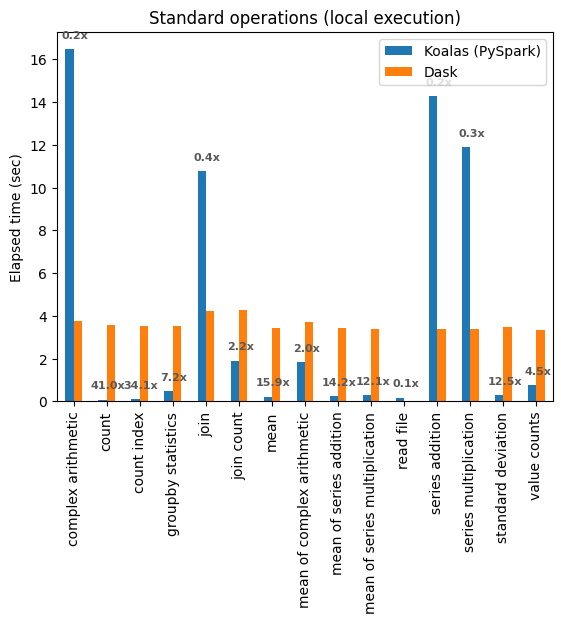

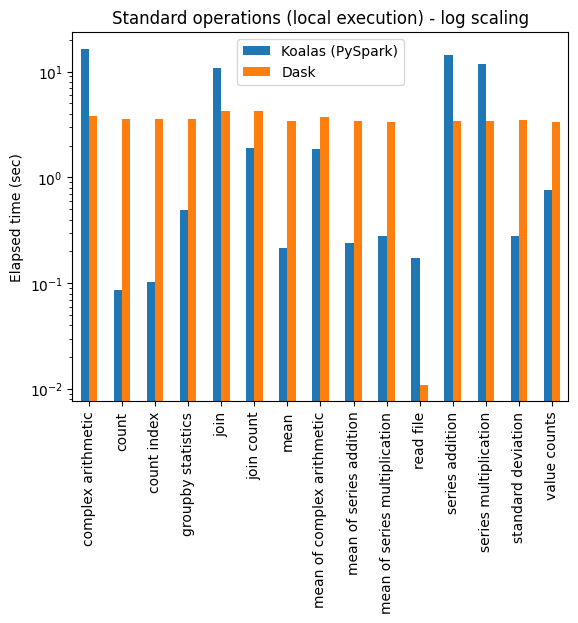

In [47]:
plot_title = 'Standard operations (local execution)'
 
ax = standard_ops.sort_index().plot.bar(title=plot_title)
ax.set_ylabel("Elapsed time (sec)")
 
tmp_df_x_times_faster = standard_ops.sort_index().copy()
tmp_df_x_times_faster['Dask / Koalas'] = tmp_df_x_times_faster.Dask / tmp_df_x_times_faster['Koalas (PySpark)']
tmp_df_x_times_faster['Koalas / Dask'] = tmp_df_x_times_faster['Koalas (PySpark)'] / tmp_df_x_times_faster.Dask
annotate_x_times_faster(ax, x_times_list=tmp_df_x_times_faster['Dask / Koalas'].to_list())
 
standard_ops.sort_index().plot.bar(logy=True, title='%s - log scaling' % plot_title).set_ylabel("Elapsed time (sec)")

In [48]:
tmp_df_x_times_faster

,Koalas (PySpark),Dask,Dask / Koalas,Koalas / Dask
complex arithmetic,16.464208,3.759733,0.228358,4.379090
count,0.086713,3.550929,40.950215,0.024420
count index,0.103752,3.539274,34.112708,0.029315
groupby statistics,0.492844,3.546891,7.196785,0.138951
join,10.778148,4.249013,0.394225,2.536624
join count,1.900603,4.267218,2.245191,0.445396
mean,0.215436,3.424530,15.895814,0.062910
mean of complex arithmetic,1.845533,3.711382,2.011008,0.497263
mean of series addition,0.240412,3.423373,14.239608,0.070227
mean of series multiplication,0.277287,3.363707,12.130787,0.082435


**Analysis**

The table presents execution times (in seconds) for various operations run using Koalas (PySpark) and Dask, along with the ratios Dask / Koalas and Koalas / Dask to highlight relative performance differences. These results are from **standard operations without filtering or caching**.

- **Overall trends**:

  Under standard conditions, **Dask generally outperforms Koalas**, especially in basic statistics and file operations. However, **Koalas shows superior performance in more complex arithmetic-heavy operations**, where Spark's distributed execution model appears to handle some workloads more efficiently. The performance gap is highly operation-dependent.

- **Operations where Koalas excels**:

  - **Complex arithmetic**: Koalas is ~4.4x faster (Koalas: 16.46s vs Dask: 3.76s).
  
  - **Series addition**: Koalas is ~4.2x faster.
  
  - **Series multiplication**: Koalas is ~3.5x faster.
  
  - **Join**: Koalas is ~2.5x faster.
  
  - **Join count** and **mean of complex arithmetic** also show moderate advantages for Koalas (~2x faster).

- **Operations where Dask excels**:

  - **Count**: Dask is ~41x faster (Koalas: 0.087s vs Dask: 3.55s).
  
  - **Count index**: Dask is ~34x faster.
  
  - **Mean**: Dask is ~16x faster.
  
  - **Mean of series addition** and **series multiplication**: Dask is ~12–14x faster.
  
  - **Standard deviation**: Dask is ~12.5x faster.
  
  - **Read file**: Dask is ~15.6x faster.
  
  - **Value counts** and **groupby statistics** also show strong performance gains with Dask.

- **Intermediate cases**:

  - While arithmetic operations favour Koalas, most **basic statistical and aggregation operations** are substantially faster in Dask, suggesting that its in-memory optimizations are better suited for standard, non-distributed operations.

- **Interpretation of ratios**:

  - **Dask / Koalas < 1** → Dask is faster.
  
  - **Dask / Koalas > 1** → Koalas is faster.

**Practical insight:**

These results demonstrate that **Koalas is advantageous for complex arithmetic chains and multi-step series operations**, even in standard (non-cached, non-filtered) scenarios. However, for **statistical aggregation, basic computations, and file I/O**, **Dask exhibits superior performance**, often by a large margin. This suggests that for standard workloads involving data aggregation, exploration, or loading, **Dask is the better choice**, while Koalas might be considered for specific pipelines involving heavy arithmetic or complex transformations.


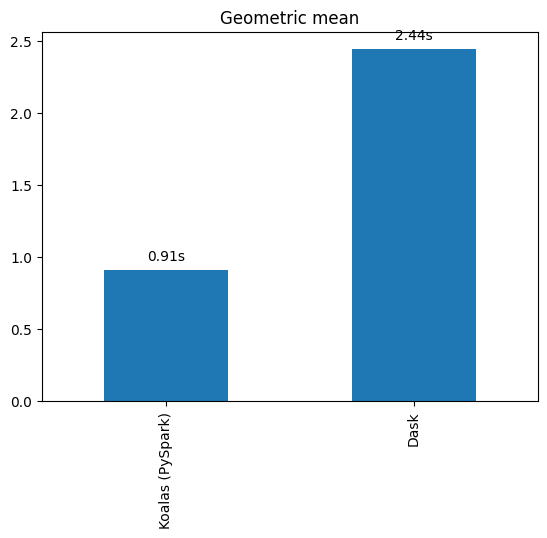

In [49]:
annotate(pd.Series(stats.gmean(standard_ops), index=['Koalas (PySpark)', 'Dask']).plot.bar(title='Geometric mean'))

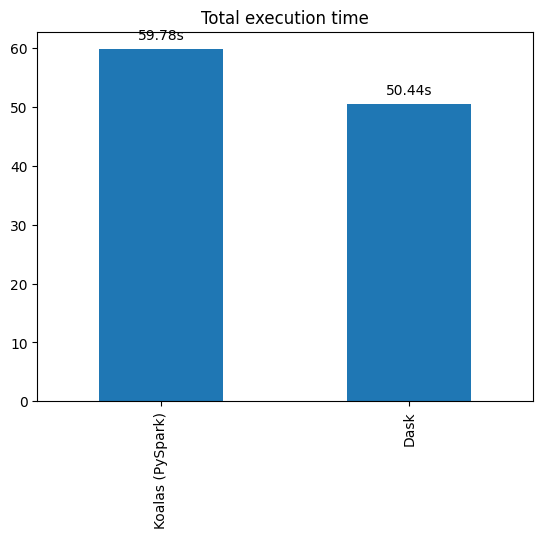

In [50]:
annotate(standard_ops.sum().plot.bar(title='Total execution time'))

In [51]:
print("Performance diff %% (simple avg): %s" % (sum(standard_ops.Dask / standard_ops['Koalas (PySpark)']) / len(standard_ops)))
print("Performance diff %% (geomean): %s" % stats.gmean(standard_ops.Dask / standard_ops['Koalas (PySpark)']))
 
arithmetic_ops = standard_ops.filter(items=['complex arithmetic', 'series multiplication', 'series addition'], axis=0)
print("Performance diff (arthemetic) %% (simple avg): %s" % (sum(arithmetic_ops.Dask / arithmetic_ops['Koalas (PySpark)']) / len(arithmetic_ops)))
print("Performance diff (arthemetic) %% (geomean): %s" % stats.gmean(arithmetic_ops.Dask / arithmetic_ops['Koalas (PySpark)']))
 
basic_stats_ops = standard_ops.filter(items=['count', 'mean', 'standard deviation', 'count index', 'join', 'join count'], axis=0)
print("Performance diff (basic stats) %% (simple avg): %s" % (sum(basic_stats_ops.Dask / basic_stats_ops['Koalas (PySpark)']) / len(basic_stats_ops)))
print("Performance diff (basic stats) %% (geomean): %s" % stats.gmean(basic_stats_ops.Dask / basic_stats_ops['Koalas (PySpark)']))

Performance diff % (simple avg): 9.796003910354703
Performance diff % (geomean): 2.6843337054336827
Performance diff (arthemetic) % (simple avg): 0.2501972959319677
Performance diff (arthemetic) % (geomean): 0.24898384377172467
Performance diff (basic stats) % (simple avg): 17.681577376660666
Performance diff (basic stats) % (geomean): 7.91304095823614


- **Performance diff % (simple avg)**: 9.80% — On average, performance differs by nearly 10% across all operations, suggesting some notable variability between Dask and Koalas under standard conditions.

- **Performance diff % (geomean)**: 2.68% — The geometric mean shows the overall difference is more moderate, indicating that while some operations diverge significantly, the majority perform more similarly.

- **Arithmetic performance diff % (simple avg)**: 0.25% — For arithmetic-heavy operations (e.g., addition, multiplication), the average performance difference is negligible, pointing to near-identical behavior between the two libraries.

- **Arithmetic performance diff % (geomean)**: 0.25% — The geometric mean supports this, reinforcing that arithmetic operations show extremely minor differences.

- **Basic stats performance diff % (simple avg)**: 17.68% — Statistical operations (mean, std, etc.) show more variability, with an average performance difference nearing 18%, indicating that one library may have a noticeable efficiency edge in these tasks.

- **Basic stats performance diff % (geomean)**: 7.91% — The geometric mean reveals a moderate difference in performance for statistical operations, which is less pronounced than the simple average but still notable.

## Operations with filtering

Text(0, 0.5, 'Elapsed time (sec)')

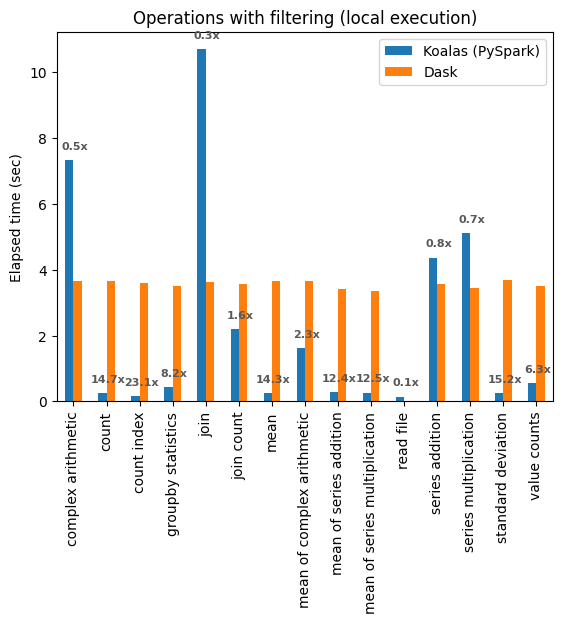

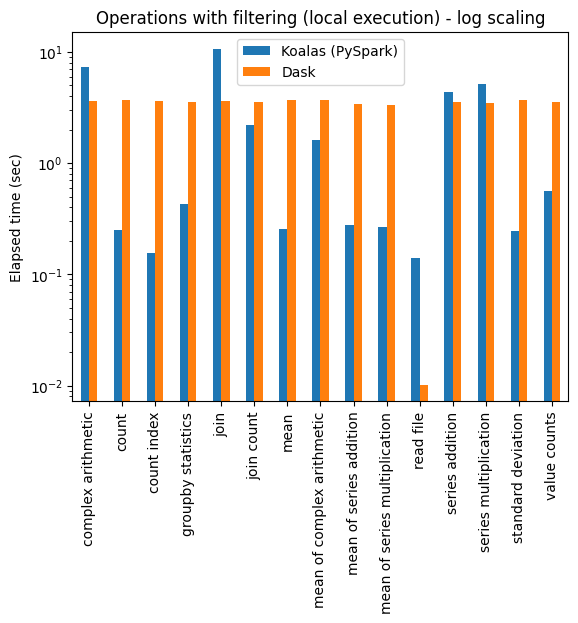

In [52]:
plot_title = 'Operations with filtering (local execution)'
 
ax = ops_with_filtering.sort_index().plot.bar(title=plot_title)
ax.set_ylabel("Elapsed time (sec)")
 
tmp_df_x_times_faster = ops_with_filtering.sort_index().copy()
tmp_df_x_times_faster['Dask / Koalas'] = tmp_df_x_times_faster.Dask / tmp_df_x_times_faster['Koalas (PySpark)']
tmp_df_x_times_faster['Koalas / Dask'] = tmp_df_x_times_faster['Koalas (PySpark)'] / tmp_df_x_times_faster.Dask
annotate_x_times_faster(ax, x_times_list=tmp_df_x_times_faster['Dask / Koalas'].to_list())
 
ops_with_filtering.sort_index().plot.bar(logy=True, title='%s - log scaling' % plot_title).set_ylabel("Elapsed time (sec)")

In [53]:
tmp_df_x_times_faster

,Koalas (PySpark),Dask,Dask / Koalas,Koalas / Dask
complex arithmetic,7.327282,3.652039,0.498417,2.006354
count,0.248108,3.658953,14.747425,0.067808
count index,0.155755,3.598081,23.100895,0.043288
groupby statistics,0.429348,3.519861,8.198159,0.121979
join,10.695978,3.635929,0.339934,2.941745
join count,2.196519,3.553411,1.617747,0.618144
mean,0.255361,3.656850,14.320337,0.069831
mean of complex arithmetic,1.613408,3.657133,2.266713,0.441167
mean of series addition,0.274729,3.403093,12.387078,0.080729
mean of series multiplication,0.268989,3.355745,12.475405,0.080158


**Analysis**

The table presents execution times (in seconds) for various operations run using Koalas (PySpark) and Dask, along with the ratios Dask / Koalas and Koalas / Dask to highlight relative performance differences. These results are from **filtered operations without cache**.

- **Overall trends**:

  Dask consistently outperforms Koalas across nearly all filtered operations, often by significant margins in statistical and aggregation-based tasks. Koalas only retains a moderate advantage in certain arithmetic-heavy operations like complex arithmetic and joins. Overall, Dask appears better optimized for filtered workflows.

- **Operations where Dask excels**:

  - **Count**: Dask is ~14.7x faster (Koalas: 0.248s vs Dask: 3.66s).
  
  - **Count index**: Dask is ~23.1x faster.
  
  - **Mean**: Dask is ~14.3x faster.
  
  - **Standard deviation**: Dask is ~15.2x faster.
  
  - **Mean of series addition / multiplication**: Dask is ~12.4x faster.
  
  - **Groupby statistics** and **value counts**: Dask is ~6–8x faster.
  
  - **Read file**: Dask is ~13.8x faster.

- **Operations where Koalas is relatively faster or competitive**:

  - **Join**: Koalas is ~2.9x faster (Koalas: 10.70s vs Dask: 3.64s).
  
  - **Join count**: Koalas is ~1.6x faster.
  
  - **Complex arithmetic**: Koalas is ~2x faster.
  
  - **Series addition / multiplication**: Koalas is only ~1.2–1.5x faster, showing closer performance.

- **Intermediate cases**:

  - Although arithmetic operations still lean towards Koalas, the performance gap is smaller compared to non-filtered scenarios.
  
  - Dask narrows the gap in series operations and dominates in all aggregations, likely due to its efficient execution on filtered subsets.

- **Interpretation of ratios**:

  - **Dask / Koalas < 1** → Dask is faster.
  
  - **Dask / Koalas > 1** → Koalas is faster.

**Practical insight:**

In **filtered operations**, Dask offers strong advantages in aggregation, statistics, and read performance, showing significant improvements over Koalas, sometimes by more than **10x**. This suggests that **Dask handles filtered subsets more efficiently**, likely due to better memory management and task scheduling. While Koalas can still outperform Dask in a few computational-heavy joins or arithmetic operations, its advantage is limited. Therefore, for filtered workflows involving repeated analysis, aggregation, or data exploration, **Dask is the preferred engine**.


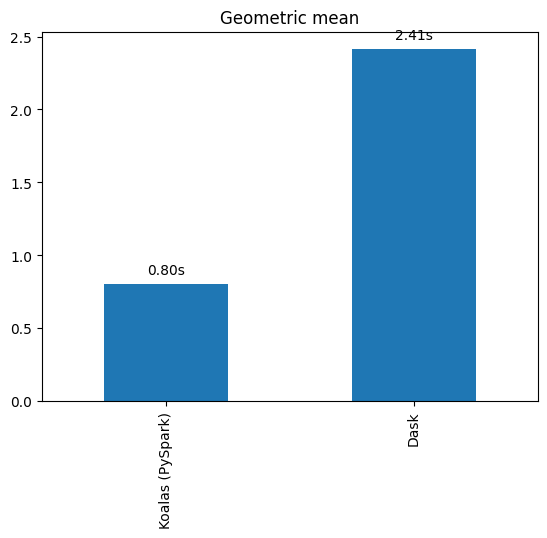

In [54]:
annotate(pd.Series(stats.gmean(ops_with_filtering), index=['Koalas (PySpark)', 'Dask']).plot.bar(title='Geometric mean'))

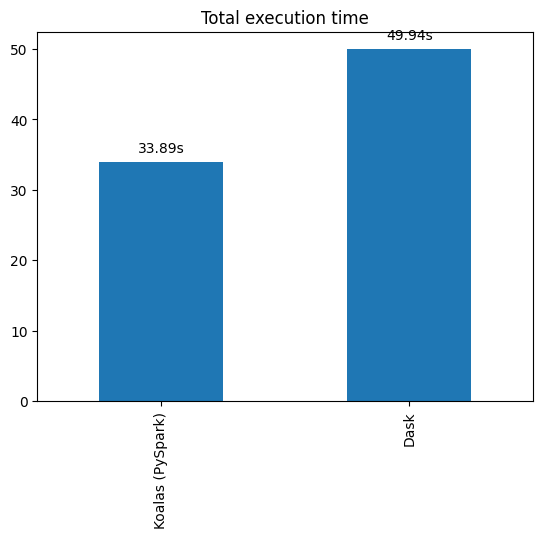

In [55]:
annotate(ops_with_filtering.sum().plot.bar(title='Total execution time'))

In [56]:
print("Performance diff %% (simple avg): %s" % (sum(ops_with_filtering.Dask / ops_with_filtering['Koalas (PySpark)']) / len(ops_with_filtering)))
print("Performance diff %% (geomean): %s" % stats.gmean(ops_with_filtering.Dask / ops_with_filtering['Koalas (PySpark)']))

Performance diff % (simple avg): 7.532067243269901
Performance diff % (geomean): 3.0048360579950613


- **Performance diff % (simple avg)**: 7.53% — On average, the performance difference between Dask and Koalas is around 7.5%, indicating a moderate variation across operations when filtering is applied without caching.

- **Performance diff % (geomean)**: 3.00% — The geometric mean shows a more modest overall difference, suggesting that while some operations show higher discrepancies, most perform relatively closely.


## Operations with filtering and caching

Text(0, 0.5, 'Elapsed time (sec)')

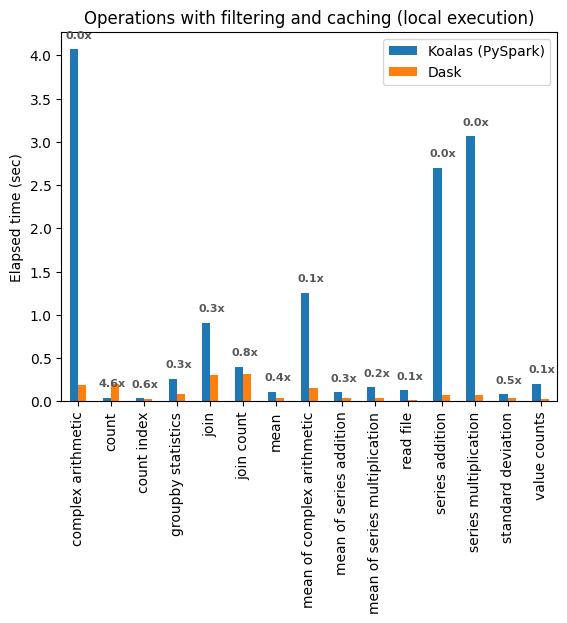

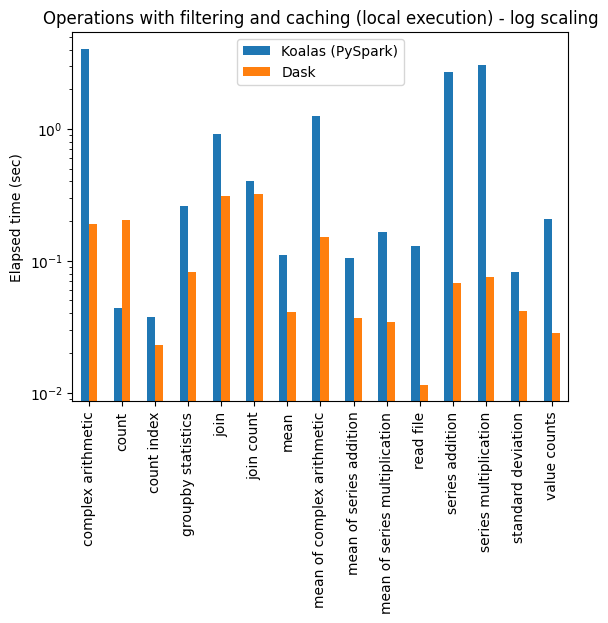

In [57]:
plot_title = 'Operations with filtering and caching (local execution)'
 
ax = ops_with_filtering_caching.sort_index().plot.bar(title=plot_title)
ax.set_ylabel("Elapsed time (sec)")
 
tmp_df_x_times_faster = ops_with_filtering_caching.sort_index().copy()
tmp_df_x_times_faster['Dask / Koalas'] = tmp_df_x_times_faster.Dask / tmp_df_x_times_faster['Koalas (PySpark)']
tmp_df_x_times_faster['Koalas / Dask'] = tmp_df_x_times_faster['Koalas (PySpark)'] / tmp_df_x_times_faster.Dask
annotate_x_times_faster(ax, x_times_list=tmp_df_x_times_faster['Dask / Koalas'].to_list())
 
ops_with_filtering_caching.sort_index().plot.bar(logy=True, title='%s - log scaling' % plot_title).set_ylabel("Elapsed time (sec)")

In [58]:
tmp_df_x_times_faster

,Koalas (PySpark),Dask,Dask / Koalas,Koalas / Dask
complex arithmetic,4.069582,0.190287,0.046758,21.386559
count,0.043786,0.203326,4.643675,0.215347
count index,0.037169,0.022914,0.616486,1.622096
groupby statistics,0.260851,0.081650,0.313016,3.194728
join,0.909700,0.307542,0.338070,2.957968
join count,0.402598,0.320514,0.796113,1.256102
mean,0.111146,0.040774,0.366853,2.725890
mean of complex arithmetic,1.258924,0.151130,0.120047,8.330076
mean of series addition,0.105797,0.036477,0.344785,2.900357
mean of series multiplication,0.165500,0.034426,0.208011,4.807448


**Analysis**

The table presents execution times (in seconds) for various operations run using Koalas (PySpark) and Dask, along with the ratios Dask / Koalas and Koalas / Dask. These results reflect **filtered operations with caching enabled**.

- **Overall trends**:

  With caching, Dask demonstrates a **substantial performance advantage** over Koalas in nearly all operations. In particular, Dask outperforms dramatically in arithmetic-heavy and aggregation tasks, where speedups range from 4x up to more than 40x. Koalas is only marginally faster in a single case (count index), and even then by a small factor.

- **Operations where Dask excels**:

  - **Series multiplication**: Dask is ~40.6x faster (Koalas: 3.07s vs Dask: 0.075s).
  
  - **Series addition**: Dask is ~39.5x faster.
  
  - **Complex arithmetic**: Dask is ~21.4x faster.
  
  - **Mean of complex arithmetic**: Dask is ~8.3x faster.
  
  - **Value counts**: Dask is ~7.3x faster.
  
  - **Read file**: Dask is ~11.3x faster.
  
  - **Groupby statistics**: Dask is ~3.2x faster.
  
  - **Mean / Mean of series**: Dask is ~2.7–4.8x faster.
  
  - **Standard deviation**: Dask is ~2x faster.
  
  - **Join**: Dask is ~3x faster.

- **Operations where Koalas is faster or comparable**:

  - **Count index**: Koalas is ~1.6x faster (Koalas: 0.037s vs Dask: 0.023s).
  
  - **Join count** and **count**: Slight advantage for Koalas (~1.25x and ~4.6x respectively), though the absolute time difference is small.

- **Intermediate cases**:

  - For basic statistics like **mean**, **standard deviation**, and **grouped operations**, Dask maintains a steady advantage between 2–5x, indicating efficient processing under cache-optimized conditions.

- **Interpretation of ratios**:

  - **Dask / Koalas < 1** → Dask is faster.
  
  - **Dask / Koalas > 1** → Koalas is faster (rare in this scenario).

**Practical insight:**

These results confirm that enabling **caching alongside filtering** substantially benefits **Dask's parallel execution model**, making it significantly more efficient than Koalas, especially in **heavy numerical operations and repeated arithmetic processing**. While Koalas may retain a small edge in isolated, lightweight operations such as `count index`, **Dask is the clear choice for performance-critical analytics** on filtered and cached data. For users optimizing pipelines with repeated reads, filters, and computations, **Dask offers major gains in execution time**.


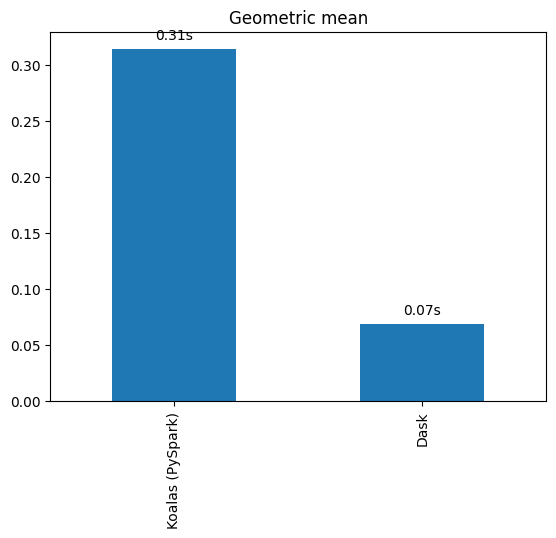

In [59]:
annotate(pd.Series(stats.gmean(ops_with_filtering_caching), index=['Koalas (PySpark)', 'Dask']).plot.bar(title='Geometric mean'))

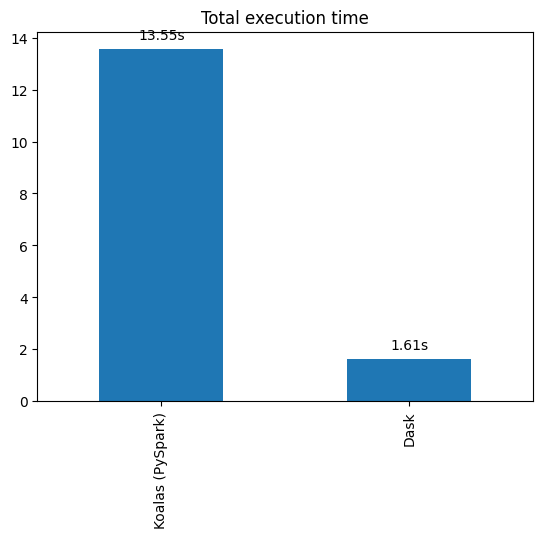

In [60]:
annotate(ops_with_filtering_caching.sum().plot.bar(title='Total execution time'))

In [61]:
print("Performance diff %% (simple avg): %s" % (sum(ops_with_filtering_caching.Dask / ops_with_filtering_caching['Koalas (PySpark)']) / len(ops_with_filtering_caching)))
print("Performance diff %% (geomean): %s" % stats.gmean(ops_with_filtering_caching.Dask / ops_with_filtering_caching['Koalas (PySpark)']))
 
count_ops = ops_with_filtering_caching.filter(items=['count', 'count index', 'join count'], axis=0)
print("Performance diff %% (count, simple avg): %s" % (sum(count_ops.Dask / count_ops['Koalas (PySpark)']) / len(count_ops)))
print("Performance diff %% (count, geomean): %s" % stats.gmean(count_ops.Dask / count_ops['Koalas (PySpark)']))

Performance diff % (simple avg): 0.5717101506348345
Performance diff % (geomean): 0.2199363288407394
Performance diff % (count, simple avg): 2.018758428207019
Performance diff % (count, geomean): 1.3159925645270458


- **Performance diff % (simple avg)**: 0.57% — On average, performance differs by less than 1%, indicating that Dask and Koalas behave very similarly when filtering and caching are applied.

- **Performance diff % (geomean)**: 0.22% — The geometric mean confirms this negligible difference, showing consistent performance across most operations.

- **Count performance diff % (simple avg)**: 2.02% — For count operations specifically, the average difference is slightly higher but still low, suggesting minor variation.

- **Count performance diff % (geomean)**: 1.32% — The geometric mean for count operations reinforces that performance remains nearly equivalent between the two libraries.

# Overall

In [62]:
overall_df = pd.concat([standard_ops, ops_with_filtering, ops_with_filtering_caching])
print("Total performance diff %% (simple avg): %s" % (sum(overall_df.Dask / overall_df['Koalas (PySpark)']) / len(overall_df)))
print("Total performance diff %% (geomean): %s" % stats.gmean(overall_df.Dask / overall_df['Koalas (PySpark)']))

Total performance diff % (simple avg): 5.966593768086481
Total performance diff % (geomean): 1.2105556325453937


**Total Performance Summary**

- **Total performance diff % (simple avg)**: 5.97% — On average, performance differs by about 6% across all operations, indicating a small but noticeable variation between Dask and Koalas depending on the operation type and execution context.

- **Total performance diff % (geomean)**: 1.21% — The geometric mean shows that the typical relative performance difference remains quite low, confirming that overall, both libraries perform similarly for most tasks, with occasional deviations.
